In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interactive
from IPython.display import display, HTML
import coordinate_transforms
import decorr_calculations
import plotting
import importlib
import matplotlib

importlib.reload(decorr_calculations)
importlib.reload(coordinate_transforms)
importlib.reload(plotting)

<module 'plotting' from '/Users/ruby/Astro/decorrelation/plotting.py'>

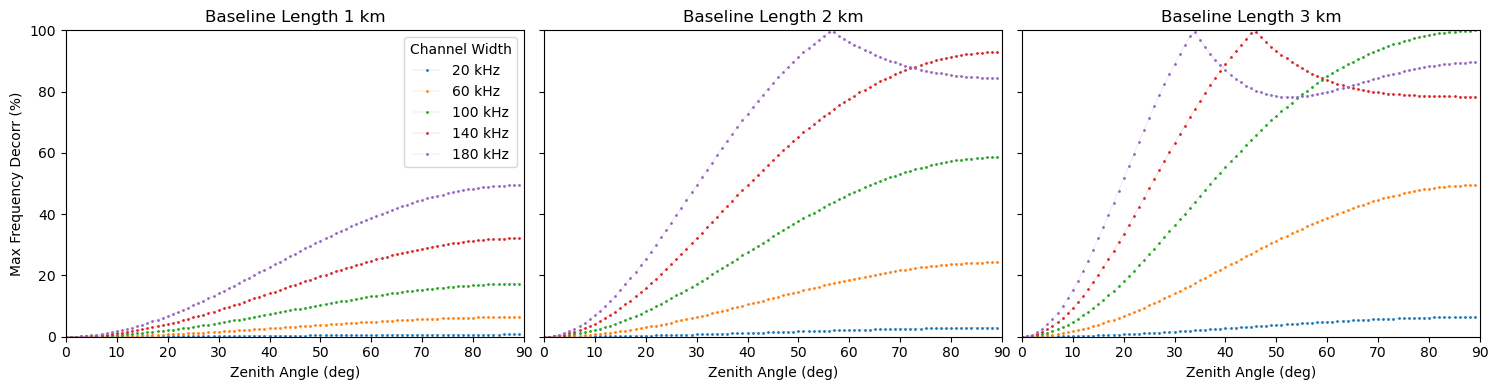

In [229]:
za_list = np.arange(0, 90)
channel_width_khz = [20, 60, 100, 140, 180]
bl_lengths = [1000, 2000, 3000]
fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharey=True
)
for plt_ind, bl_length_m in enumerate(bl_lengths):
    for chan_width in channel_width_khz:
        freq_decorr = decorr_calculations.max_fractional_freq_decorr(
            chan_width * 1e3,
            bl_length_m,
            za_list,
        )
        # print(freq_decorr[np.where(za_list==30)])
        ax[plt_ind].plot(
            za_list,
            freq_decorr*100,
            ".-",
            markersize=2,
            linewidth=0.1,
            label=f"{chan_width} kHz",
        )
    ax[plt_ind].set_ylim(0, 100)
    ax[plt_ind].set_xlim(0, 90)
    ax[plt_ind].set_xlabel("Zenith Angle (deg)")
    ax[plt_ind].set_title(f"Baseline Length {int(bl_length_m/1e3)} km")
ax[0].set_ylabel("Max Frequency Decorr (%)")
ax[0].legend(title="Channel Width")
plt.tight_layout()
plt.savefig("/Users/ruby/Downloads/freq_decorr_max.png", dpi=300)

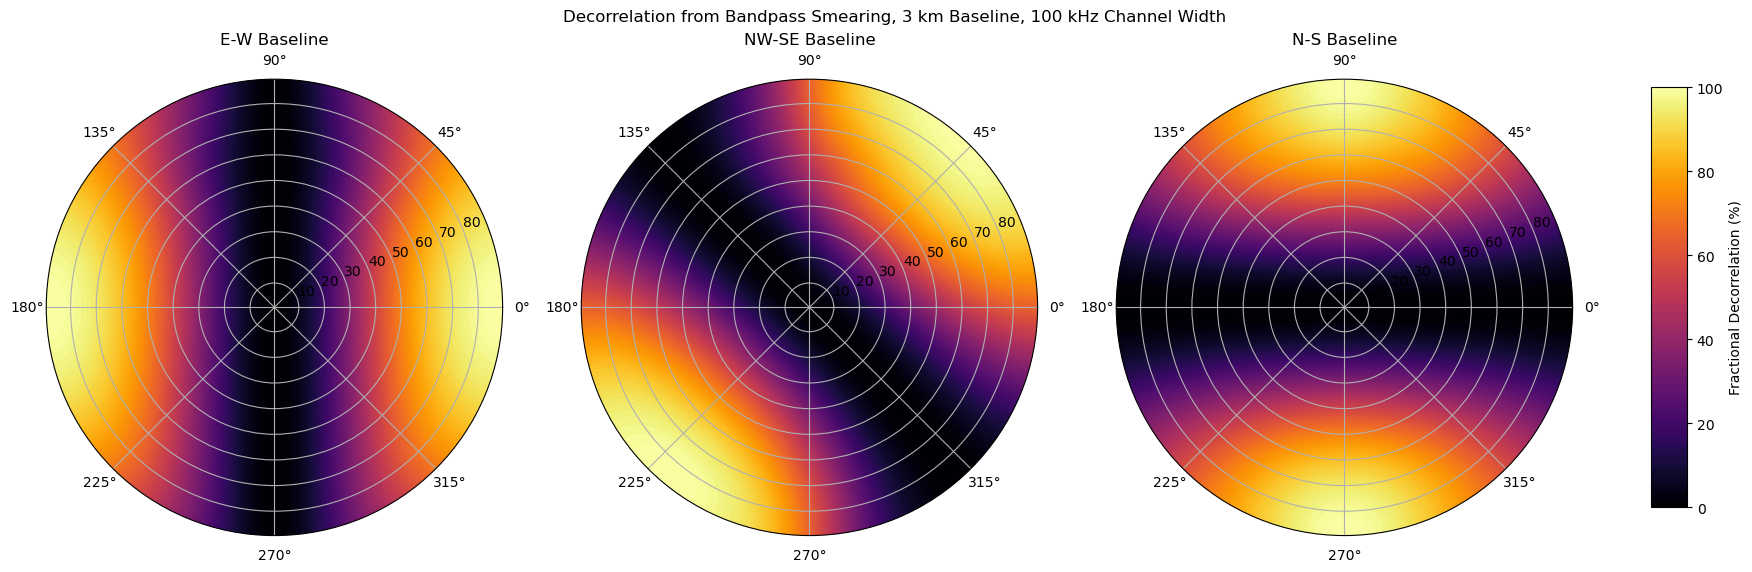

In [80]:
bl_length = 3000
telescope_lat = 37
time_resolution_s = 0
freq_resolution_kHz = 100
freq_hz = 300e6
mark_north_pole=False
titles = ["E-W Baseline", "NW-SE Baseline", "N-S Baseline"]

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    subplot_kw=dict(projection="polar"),
    figsize=(18, 6),
)
for fig_ind, bl_orientation in enumerate([0, 45, 90]):
    bl_ew_extent_m = bl_length * np.cos(np.radians(bl_orientation))
    bl_ns_extent_m = bl_length * np.sin(np.radians(bl_orientation))

    za_vals = np.arange(0, 90, 1) + 0.5
    az_vals = np.arange(0, 370, 1) + 0.5
    az_array, za_array = np.meshgrid(az_vals, za_vals)
    ra_vals, dec_vals = coordinate_transforms.az_za_to_ra_dec(
        az_array,  # Units degrees
        za_array,  # Units degrees
        0,  # Units hours (RA of zenith)
        telescope_lat,  # Units degrees
    )

    decorr_values = decorr_calculations.fractional_decorr_general(
        time_resolution_s,
        1,
        freq_resolution_kHz * 1e3,
        freq_hz,
        bl_ew_extent_m,
        bl_ns_extent_m,
        ra_vals,
        dec_vals,
        phase_center_ra_offset_hr=0,
        phase_center_dec_deg=telescope_lat,
        telescope_lat_deg=telescope_lat,
    )

    use_cmap = matplotlib.colormaps["inferno"]
    use_cmap.set_bad(color="whitesmoke")

    # Set contour levels
    levels = np.linspace(0, 100, num=100)

    contourplot = ax[fig_ind].contourf(
        np.deg2rad(az_vals),
        za_vals,
        decorr_values*100,
        levels,
        vmin=0,
        vmax=100,
        cmap=use_cmap,
    )
    if mark_north_pole:
        ax[fig_ind].plot([np.pi / 2], [90 - telescope_lat], "x", color="white", linewidth=0)
        ax[fig_ind].annotate(
            "North Pole",
            xy=(np.pi / 2, 90 - telescope_lat),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            color="white",
            # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
            # arrowprops=dict(
            #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
            # ),
        )
    contourplot.set_clim(vmin=0, vmax=100)
    ax[fig_ind].set_title(titles[fig_ind])
    

# Reserve space on the right for the colorbar, then lay out the rest normally
fig.tight_layout(rect=[0, 0, 0.9, 1])

# Add a shared colorbar in that reserved space
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(contourplot, cax=cbar_ax, ticks=np.linspace(0, 100, 6))
cbar.set_label("Fractional Decorrelation (%)")

fig.suptitle(f"Decorrelation from Bandpass Smearing, {int(bl_length/1e3)} km Baseline, {freq_resolution_kHz} kHz Channel Width")
plt.savefig("/Users/ruby/Downloads/freq_decorr_maps.png", dpi=300)

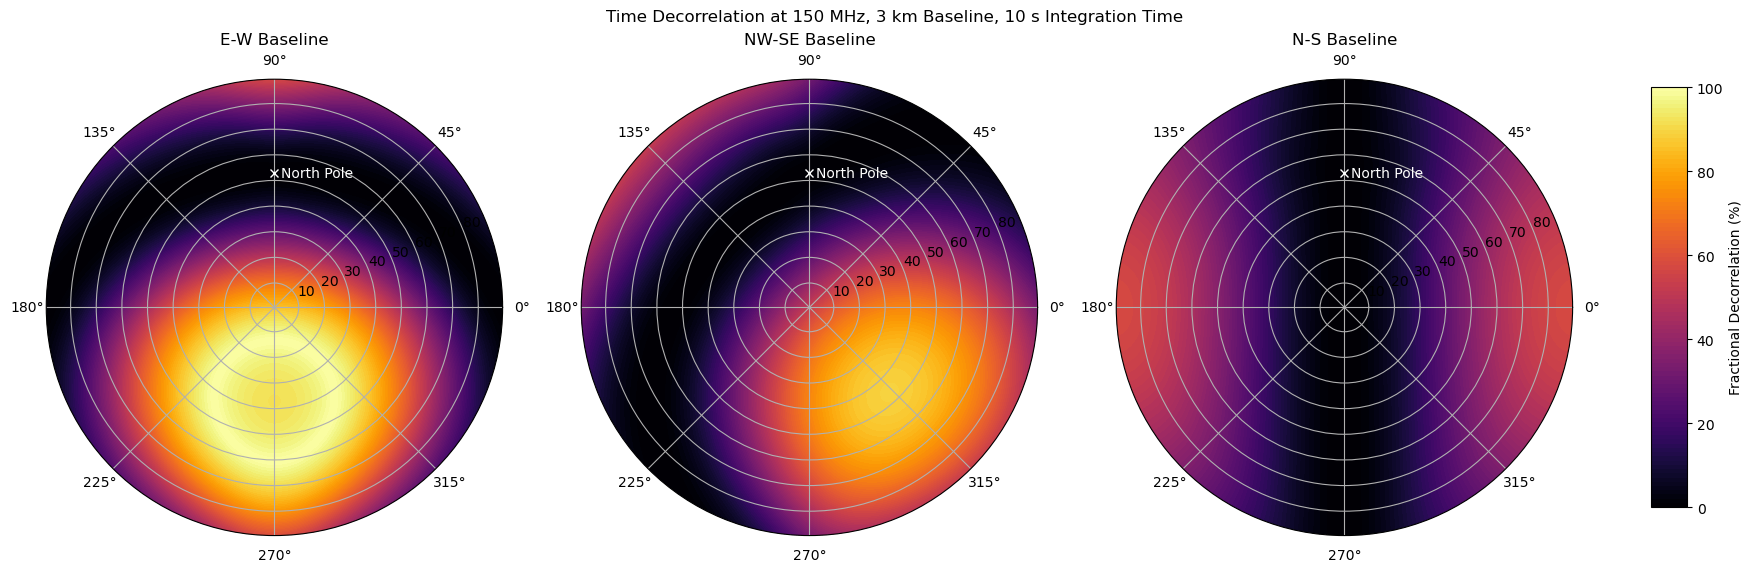

In [88]:
bl_length = 3000
telescope_lat = 37
time_resolution_s = 10
freq_resolution_kHz = 0
freq_hz = 150e6
mark_north_pole=True
titles = ["E-W Baseline", "NW-SE Baseline", "N-S Baseline"]

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    subplot_kw=dict(projection="polar"),
    figsize=(18, 6),
)
for fig_ind, bl_orientation in enumerate([0, 45, 90]):
    bl_ew_extent_m = bl_length * np.cos(np.radians(bl_orientation))
    bl_ns_extent_m = bl_length * np.sin(np.radians(bl_orientation))

    za_vals = np.arange(0, 90, 1) + 0.5
    az_vals = np.arange(0, 370, 1) + 0.5
    az_array, za_array = np.meshgrid(az_vals, za_vals)
    ra_vals, dec_vals = coordinate_transforms.az_za_to_ra_dec(
        az_array,  # Units degrees
        za_array,  # Units degrees
        0,  # Units hours (RA of zenith)
        telescope_lat,  # Units degrees
    )

    decorr_values = decorr_calculations.fractional_decorr_general(
        time_resolution_s,
        1,
        freq_resolution_kHz * 1e3,
        freq_hz,
        bl_ew_extent_m,
        bl_ns_extent_m,
        ra_vals,
        dec_vals,
        phase_center_ra_offset_hr=0,
        phase_center_dec_deg=telescope_lat,
        telescope_lat_deg=telescope_lat,
    )

    use_cmap = matplotlib.colormaps["inferno"]
    use_cmap.set_bad(color="whitesmoke")

    # Set contour levels
    levels = np.linspace(0, 100, num=100)

    contourplot = ax[fig_ind].contourf(
        np.deg2rad(az_vals),
        za_vals,
        decorr_values*100,
        levels,
        vmin=0,
        vmax=100,
        cmap=use_cmap,
    )
    if mark_north_pole:
        ax[fig_ind].plot([np.pi / 2], [90 - telescope_lat], "x", color="white", linewidth=0)
        ax[fig_ind].annotate(
            "North Pole",
            xy=(np.pi / 2, 90 - telescope_lat),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            color="white",
            # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
            # arrowprops=dict(
            #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
            # ),
        )
    contourplot.set_clim(vmin=0, vmax=100)
    ax[fig_ind].set_title(titles[fig_ind])
    

# Reserve space on the right for the colorbar, then lay out the rest normally
fig.tight_layout(rect=[0, 0, 0.9, 1])

# Add a shared colorbar in that reserved space
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(contourplot, cax=cbar_ax, ticks=np.linspace(0, 100, 6))
cbar.set_label("Fractional Decorrelation (%)")

fig.suptitle(f"Time Decorrelation at {int(freq_hz/1e6)} MHz, {int(bl_length/1e3)} km Baseline, {time_resolution_s} s Integration Time")
plt.savefig("/Users/ruby/Downloads/time_decorr_maps.png", dpi=300)

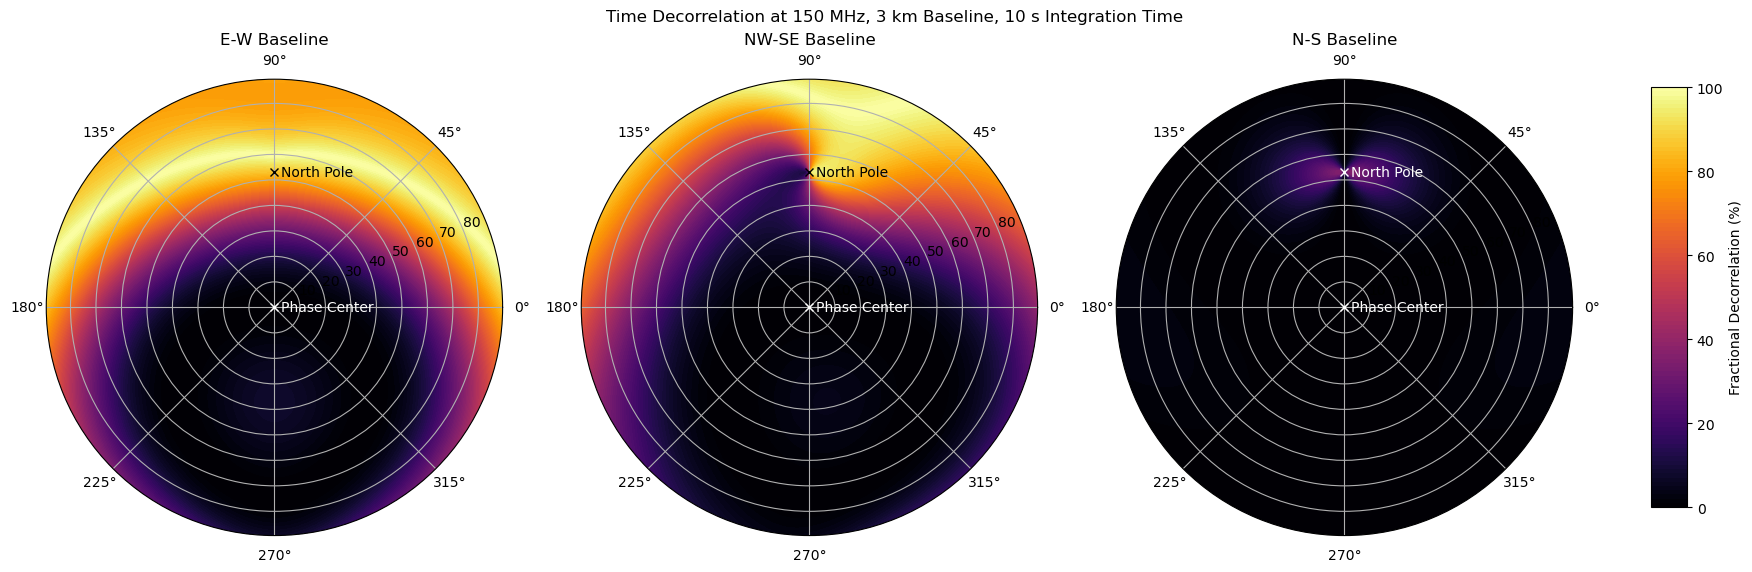

In [91]:
bl_length = 3000
telescope_lat = 37
time_resolution_s = 10
freq_resolution_kHz = 0
freq_hz = 150e6
mark_north_pole=True
titles = ["E-W Baseline", "NW-SE Baseline", "N-S Baseline"]
annotation_color = ["black", "black", "white"]

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    subplot_kw=dict(projection="polar"),
    figsize=(18, 6),
)
for fig_ind, bl_orientation in enumerate([0, 45, 90]):
    bl_ew_extent_m = bl_length * np.cos(np.radians(bl_orientation))
    bl_ns_extent_m = bl_length * np.sin(np.radians(bl_orientation))

    za_vals = np.arange(0, 90, 1) + 0.5
    az_vals = np.arange(0, 370, 1) + 0.5
    az_array, za_array = np.meshgrid(az_vals, za_vals)
    ra_vals, dec_vals = coordinate_transforms.az_za_to_ra_dec(
        az_array,  # Units degrees
        za_array,  # Units degrees
        0,  # Units hours (RA of zenith)
        telescope_lat,  # Units degrees
    )

    decorr_values = decorr_calculations.fractional_decorr_general(
        time_resolution_s,
        np.inf,
        freq_resolution_kHz * 1e3,
        freq_hz,
        bl_ew_extent_m,
        bl_ns_extent_m,
        ra_vals,
        dec_vals,
        phase_center_ra_offset_hr=0,
        phase_center_dec_deg=telescope_lat,
        telescope_lat_deg=telescope_lat,
    )

    use_cmap = matplotlib.colormaps["inferno"]
    use_cmap.set_bad(color="whitesmoke")

    # Set contour levels
    levels = np.linspace(0, 100, num=100)

    contourplot = ax[fig_ind].contourf(
        np.deg2rad(az_vals),
        za_vals,
        decorr_values*100,
        levels,
        vmin=0,
        vmax=100,
        cmap=use_cmap,
    )
    if mark_north_pole:
        ax[fig_ind].plot([np.pi / 2], [90 - telescope_lat], "x", color=annotation_color[fig_ind], linewidth=0)
        ax[fig_ind].annotate(
            "North Pole",
            xy=(np.pi / 2, 90 - telescope_lat),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            color=annotation_color[fig_ind],
            # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
            # arrowprops=dict(
            #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
            # ),
        )
    ax[fig_ind].plot([np.pi / 2], [0], "x", color="white", linewidth=0)
    ax[fig_ind].annotate(
        "Phase Center",
        xy=(np.pi / 2, 0),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        color="white",
        # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
        # arrowprops=dict(
        #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
        # ),
    )
    contourplot.set_clim(vmin=0, vmax=100)
    ax[fig_ind].set_title(titles[fig_ind])
    

# Reserve space on the right for the colorbar, then lay out the rest normally
fig.tight_layout(rect=[0, 0, 0.9, 1])

# Add a shared colorbar in that reserved space
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(contourplot, cax=cbar_ax, ticks=np.linspace(0, 100, 6))
cbar.set_label("Fractional Decorrelation (%)")

fig.suptitle(f"Time Decorrelation at {int(freq_hz/1e6)} MHz, {int(bl_length/1e3)} km Baseline, {time_resolution_s} s Integration Time")
plt.savefig("/Users/ruby/Downloads/time_decorr_maps_with_phasing.png", dpi=300)

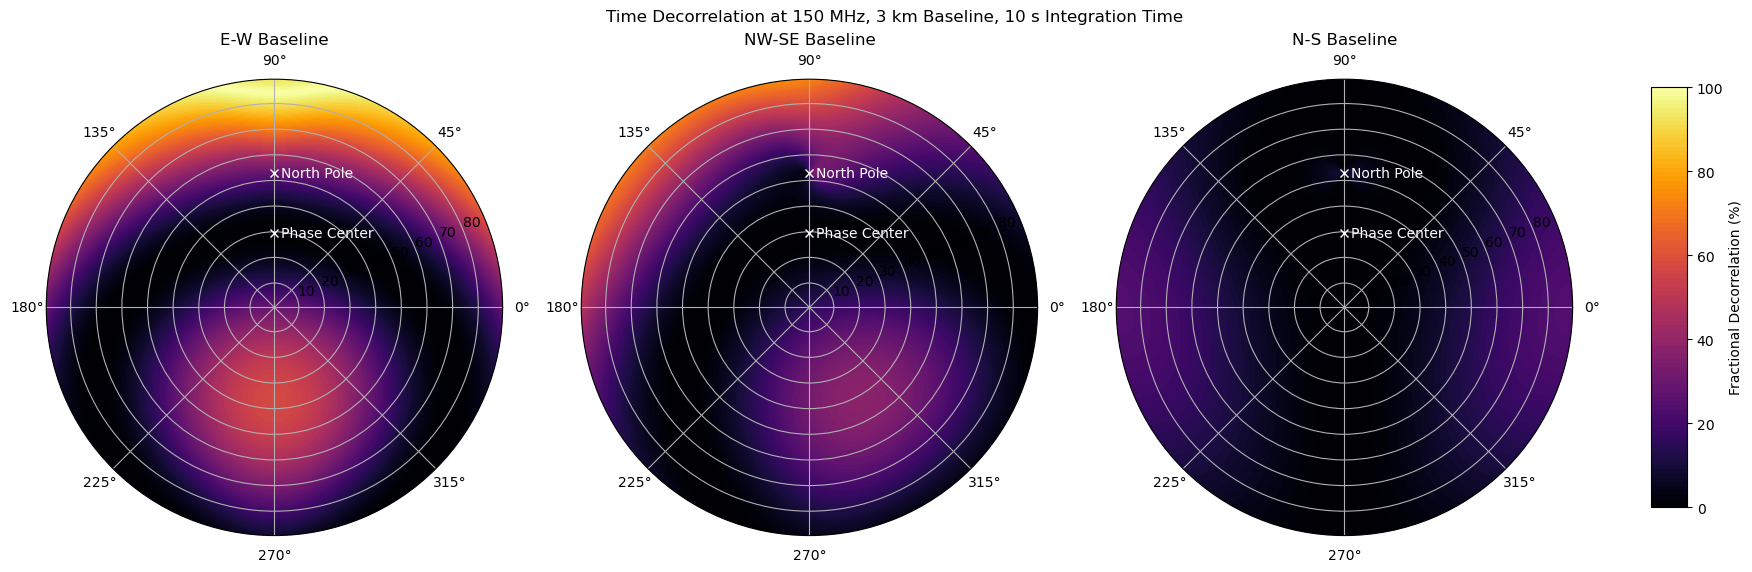

In [95]:
phase_center_dec_deg=66.45
bl_length = 3000
telescope_lat = 37
time_resolution_s = 10
freq_resolution_kHz = 0
freq_hz = 150e6
mark_north_pole=True
titles = ["E-W Baseline", "NW-SE Baseline", "N-S Baseline"]

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    subplot_kw=dict(projection="polar"),
    figsize=(18, 6),
)
for fig_ind, bl_orientation in enumerate([0, 45, 90]):
    bl_ew_extent_m = bl_length * np.cos(np.radians(bl_orientation))
    bl_ns_extent_m = bl_length * np.sin(np.radians(bl_orientation))

    za_vals = np.arange(0, 90, 1) + 0.5
    az_vals = np.arange(0, 370, 1) + 0.5
    az_array, za_array = np.meshgrid(az_vals, za_vals)
    ra_vals, dec_vals = coordinate_transforms.az_za_to_ra_dec(
        az_array,  # Units degrees
        za_array,  # Units degrees
        0,  # Units hours (RA of zenith)
        telescope_lat,  # Units degrees
    )

    decorr_values = decorr_calculations.fractional_decorr_general(
        time_resolution_s,
        np.inf,
        freq_resolution_kHz * 1e3,
        freq_hz,
        bl_ew_extent_m,
        bl_ns_extent_m,
        ra_vals,
        dec_vals,
        phase_center_ra_offset_hr=0,
        phase_center_dec_deg=phase_center_dec_deg,
        telescope_lat_deg=telescope_lat,
    )

    use_cmap = matplotlib.colormaps["inferno"]
    use_cmap.set_bad(color="whitesmoke")

    # Set contour levels
    levels = np.linspace(0, 100, num=100)

    contourplot = ax[fig_ind].contourf(
        np.deg2rad(az_vals),
        za_vals,
        decorr_values*100,
        levels,
        vmin=0,
        vmax=100,
        cmap=use_cmap,
    )
    if mark_north_pole:
        ax[fig_ind].plot([np.pi / 2], [90 - telescope_lat], "x", color="white", linewidth=0)
        ax[fig_ind].annotate(
            "North Pole",
            xy=(np.pi / 2, 90 - telescope_lat),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            color="white",
            # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
            # arrowprops=dict(
            #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
            # ),
        )
    ax[fig_ind].plot([np.pi / 2], [phase_center_dec_deg - telescope_lat], "x", color="white", linewidth=0)
    ax[fig_ind].annotate(
        "Phase Center",
        xy=(np.pi / 2, phase_center_dec_deg - telescope_lat),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        color="white",
        # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
        # arrowprops=dict(
        #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
        # ),
    )
    contourplot.set_clim(vmin=0, vmax=100)
    ax[fig_ind].set_title(titles[fig_ind])
    

# Reserve space on the right for the colorbar, then lay out the rest normally
fig.tight_layout(rect=[0, 0, 0.9, 1])

# Add a shared colorbar in that reserved space
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(contourplot, cax=cbar_ax, ticks=np.linspace(0, 100, 6))
cbar.set_label("Fractional Decorrelation (%)")

fig.suptitle(f"Time Decorrelation at {int(freq_hz/1e6)} MHz, {int(bl_length/1e3)} km Baseline, {time_resolution_s} s Integration Time")
plt.savefig("/Users/ruby/Downloads/time_decorr_maps_with_phasing_optimal.png", dpi=300)

In [49]:
phase_center_dec_deg=66.45
telescope_lat = 37

za_vals = np.arange(0, 90, 1) + 0.5
az_vals = np.arange(0, 370, 1) + 0.5
az_array, za_array = np.meshgrid(az_vals, za_vals)
ra_vals, dec_vals = coordinate_transforms.az_za_to_ra_dec(
    az_array,  # Units degrees
    za_array,  # Units degrees
    0,  # Units hours (RA of zenith)
    telescope_lat,  # Units degrees
)

bl_lengths_m = np.linspace(0, 10000, 100)
time_resolutions_s = np.linspace(0, 10, 50)
use_freqs = [50e6, 150e6, 250e6]
max_decorr = np.zeros((len(use_freqs), len(bl_lengths_m), len(time_resolutions_s)), dtype=float)
for freq_ind, freq_hz in enumerate(use_freqs):
    for bl_ind, bl_length in enumerate(bl_lengths_m):
        for time_ind, time_res in enumerate(time_resolutions_s):
            decorr_values = decorr_calculations.fractional_decorr_general(
                time_res,
                1,
                0,
                freq_hz,
                bl_length,
                0,
                ra_vals,
                dec_vals,
                phase_center_ra_offset_hr=0,
                phase_center_dec_deg=phase_center_dec_deg,
                telescope_lat_deg=telescope_lat,
            )
            max_decorr[freq_ind, bl_ind, time_ind] = np.max(decorr_values)

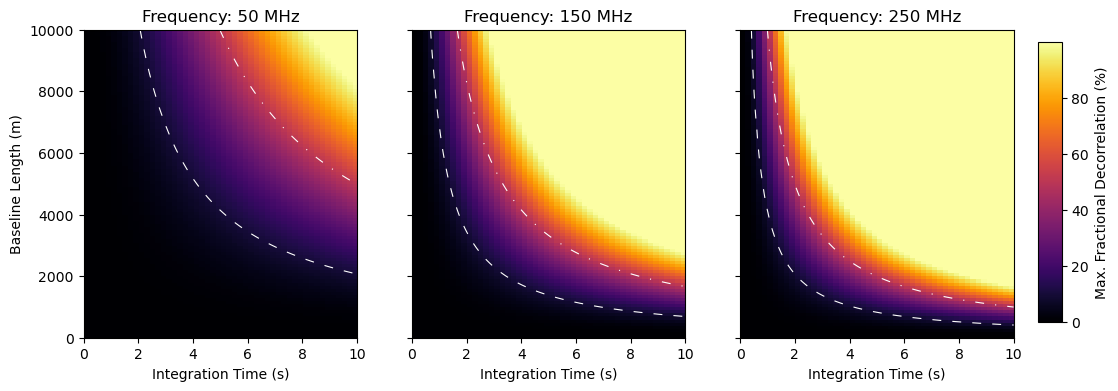

In [68]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(12, 4),
    sharey=True,
)
for ax_ind in range(3):

    use_cmap = matplotlib.colormaps["inferno"]
    im = ax[ax_ind].imshow(
        max_decorr[ax_ind, :, :]*100,
        interpolation=None,
        origin="lower", 
        extent=(np.min(time_resolutions_s), np.max(time_resolutions_s), np.min(bl_lengths_m), np.max(bl_lengths_m)),
        aspect="auto",
        cmap=use_cmap,
    )
    time_res_meshgrid, bl_lengths_meshgrid = np.meshgrid(time_resolutions_s, bl_lengths_m)
    ax[ax_ind].set_xlabel("Integration Time (s)")
    ax[ax_ind].contour(time_res_meshgrid, bl_lengths_meshgrid, max_decorr[ax_ind, :, :]*100, levels=[10, 50], colors='white', linestyles=[(0,(8,10)), (0, (8,10,1,10))], linewidths=.8)
    ax[ax_ind].set_title(f"Frequency: {int(use_freqs[ax_ind]/1e6)} MHz")

#fig.tight_layout(rect=[0, 0, 0.9, 1])

ax[0].set_ylabel("Baseline Length (m)")
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, ticks=np.linspace(0, 100, 6))
cbar.set_label("Max. Fractional Decorrelation (%)")
plt.savefig("/Users/ruby/Downloads/max_decorr.png", dpi=300)

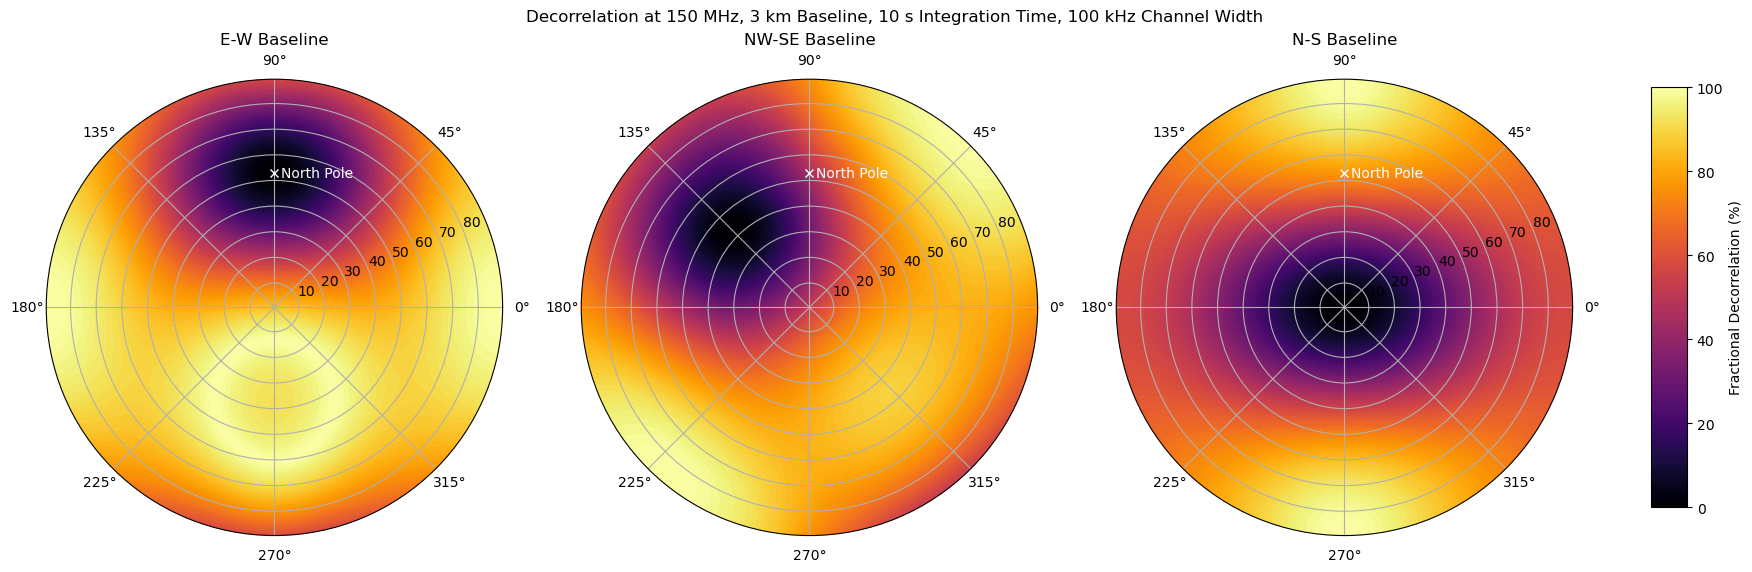

In [110]:
phase_center_dec_deg=66.45
bl_length = 3000
telescope_lat = 37
time_resolution_s = 10
freq_resolution_kHz = 100
freq_hz = 150e6
mark_north_pole=True
titles = ["E-W Baseline", "NW-SE Baseline", "N-S Baseline"]

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    subplot_kw=dict(projection="polar"),
    figsize=(18, 6),
)
for fig_ind, bl_orientation in enumerate([0, 45, 90]):
    bl_ew_extent_m = bl_length * np.cos(np.radians(bl_orientation))
    bl_ns_extent_m = bl_length * np.sin(np.radians(bl_orientation))

    za_vals = np.arange(0, 90, 1) + 0.5
    az_vals = np.arange(0, 370, 1) + 0.5
    az_array, za_array = np.meshgrid(az_vals, za_vals)
    ra_vals, dec_vals = coordinate_transforms.az_za_to_ra_dec(
        az_array,  # Units degrees
        za_array,  # Units degrees
        0,  # Units hours (RA of zenith)
        telescope_lat,  # Units degrees
    )

    decorr_values = decorr_calculations.fractional_decorr_general(
        time_resolution_s,
        1,
        freq_resolution_kHz * 1e3,
        freq_hz,
        bl_ew_extent_m,
        bl_ns_extent_m,
        ra_vals,
        dec_vals,
        phase_center_ra_offset_hr=0,
        phase_center_dec_deg=phase_center_dec_deg,
        telescope_lat_deg=telescope_lat,
    )

    use_cmap = matplotlib.colormaps["inferno"]
    use_cmap.set_bad(color="whitesmoke")

    # Set contour levels
    levels = np.linspace(0, 100, num=100)

    contourplot = ax[fig_ind].contourf(
        np.deg2rad(az_vals),
        za_vals,
        decorr_values*100,
        levels,
        vmin=0,
        vmax=100,
        cmap=use_cmap,
    )
    if mark_north_pole:
        ax[fig_ind].plot([np.pi / 2], [90 - telescope_lat], "x", color="white", linewidth=0)
        ax[fig_ind].annotate(
            "North Pole",
            xy=(np.pi / 2, 90 - telescope_lat),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            color="white",
            # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
            # arrowprops=dict(
            #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
            # ),
        )
    contourplot.set_clim(vmin=0, vmax=100)
    ax[fig_ind].set_title(titles[fig_ind])
    

# Reserve space on the right for the colorbar, then lay out the rest normally
fig.tight_layout(rect=[0, 0, 0.9, 1])

# Add a shared colorbar in that reserved space
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(contourplot, cax=cbar_ax, ticks=np.linspace(0, 100, 6))
cbar.set_label("Fractional Decorrelation (%)")

fig.suptitle(f"Decorrelation at {int(freq_hz/1e6)} MHz, {int(bl_length/1e3)} km Baseline, {time_resolution_s} s Integration Time, {freq_resolution_kHz} kHz Channel Width")
plt.savefig("/Users/ruby/Downloads/total_decorr_maps.png", dpi=300)


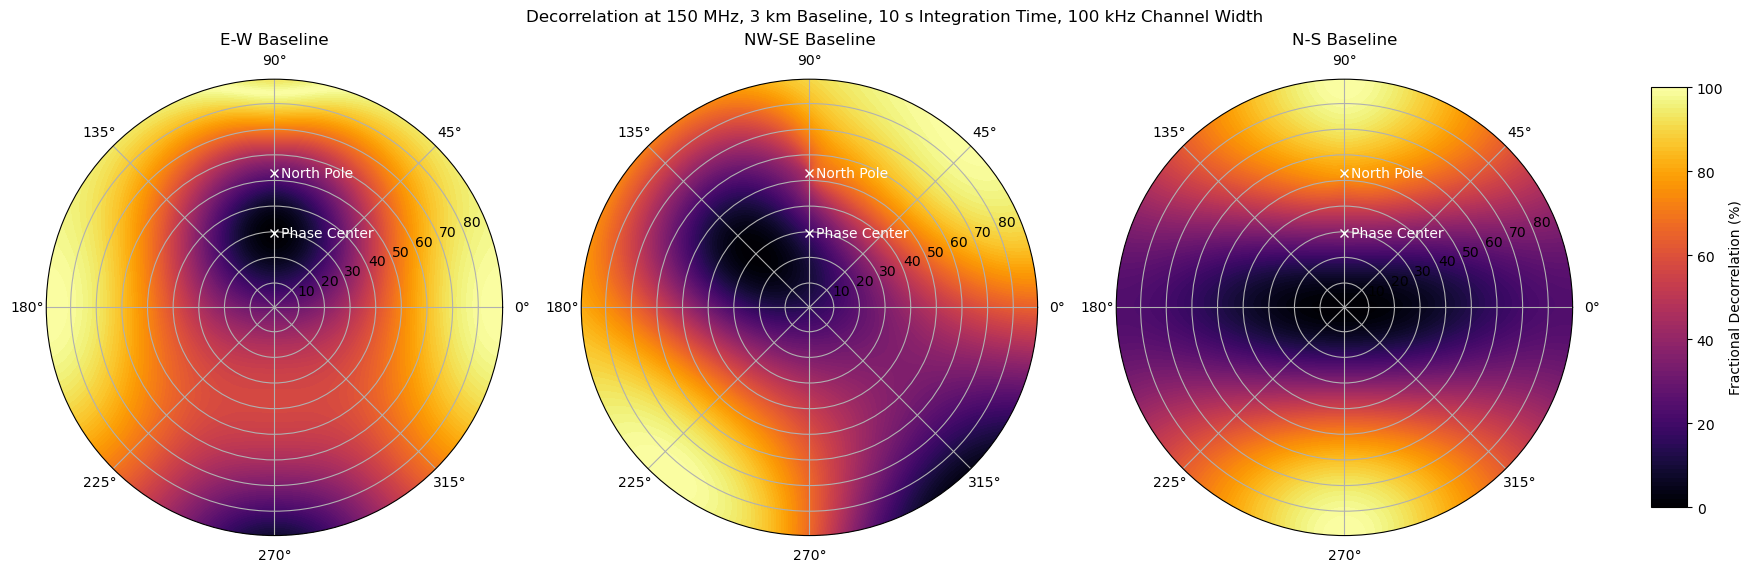

In [108]:
phase_center_dec_deg=66.45
bl_length = 3000
telescope_lat = 37
time_resolution_s = 10
freq_resolution_kHz = 100
freq_hz = 150e6
mark_north_pole=True
titles = ["E-W Baseline", "NW-SE Baseline", "N-S Baseline"]

fig, ax = plt.subplots(
    nrows=1,
    ncols=3,
    subplot_kw=dict(projection="polar"),
    figsize=(18, 6),
)
for fig_ind, bl_orientation in enumerate([0, 45, 90]):
    bl_ew_extent_m = bl_length * np.cos(np.radians(bl_orientation))
    bl_ns_extent_m = bl_length * np.sin(np.radians(bl_orientation))

    za_vals = np.arange(0, 90, 1) + 0.5
    az_vals = np.arange(0, 370, 1) + 0.5
    az_array, za_array = np.meshgrid(az_vals, za_vals)
    ra_vals, dec_vals = coordinate_transforms.az_za_to_ra_dec(
        az_array,  # Units degrees
        za_array,  # Units degrees
        0,  # Units hours (RA of zenith)
        telescope_lat,  # Units degrees
    )

    decorr_values = decorr_calculations.fractional_decorr_general(
        time_resolution_s,
        np.inf,
        freq_resolution_kHz * 1e3,
        freq_hz,
        bl_ew_extent_m,
        bl_ns_extent_m,
        ra_vals,
        dec_vals,
        phase_center_ra_offset_hr=0,
        phase_center_dec_deg=phase_center_dec_deg,
        telescope_lat_deg=telescope_lat,
    )

    use_cmap = matplotlib.colormaps["inferno"]
    use_cmap.set_bad(color="whitesmoke")

    # Set contour levels
    levels = np.linspace(0, 100, num=100)

    contourplot = ax[fig_ind].contourf(
        np.deg2rad(az_vals),
        za_vals,
        decorr_values*100,
        levels,
        vmin=0,
        vmax=100,
        cmap=use_cmap,
    )
    if mark_north_pole:
        ax[fig_ind].plot([np.pi / 2], [90 - telescope_lat], "x", color="white", linewidth=0)
        ax[fig_ind].annotate(
            "North Pole",
            xy=(np.pi / 2, 90 - telescope_lat),
            xytext=(5, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            color="white",
            # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
            # arrowprops=dict(
            #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
            # ),
        )
    ax[fig_ind].plot([np.pi / 2], [phase_center_dec_deg - telescope_lat], "x", color="white", linewidth=0)
    ax[fig_ind].annotate(
        "Phase Center",
        xy=(np.pi / 2, phase_center_dec_deg - telescope_lat),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        color="white",
        # bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.3),
        # arrowprops=dict(
        #    arrowstyle="->", connectionstyle="arc3,rad=0.5", color="red"
        # ),
    )
    contourplot.set_clim(vmin=0, vmax=100)
    ax[fig_ind].set_title(titles[fig_ind])
    

# Reserve space on the right for the colorbar, then lay out the rest normally
fig.tight_layout(rect=[0, 0, 0.9, 1])

# Add a shared colorbar in that reserved space
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(contourplot, cax=cbar_ax, ticks=np.linspace(0, 100, 6))
cbar.set_label("Fractional Decorrelation (%)")

fig.suptitle(f"Decorrelation at {int(freq_hz/1e6)} MHz, {int(bl_length/1e3)} km Baseline, {time_resolution_s} s Integration Time, {freq_resolution_kHz} kHz Channel Width")
plt.savefig("/Users/ruby/Downloads/total_decorr_maps_with_phasing.png", dpi=300)


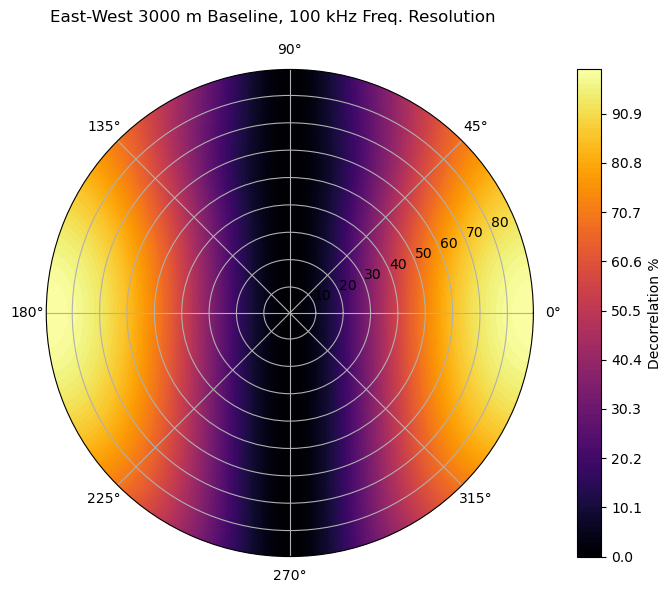

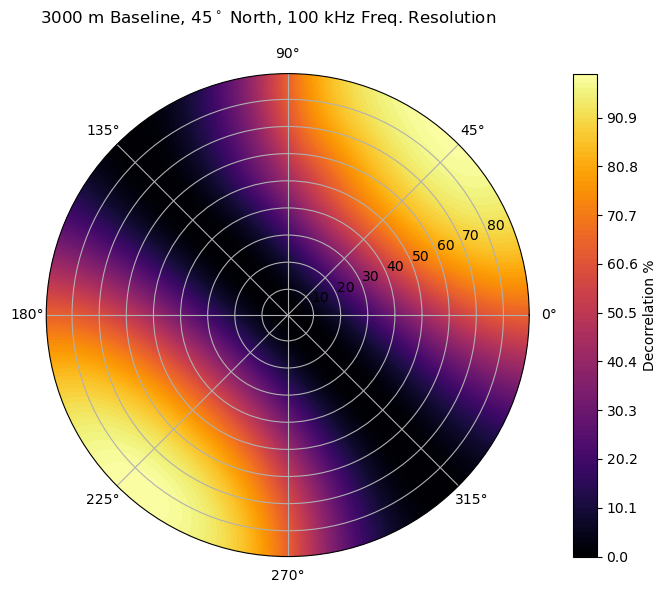

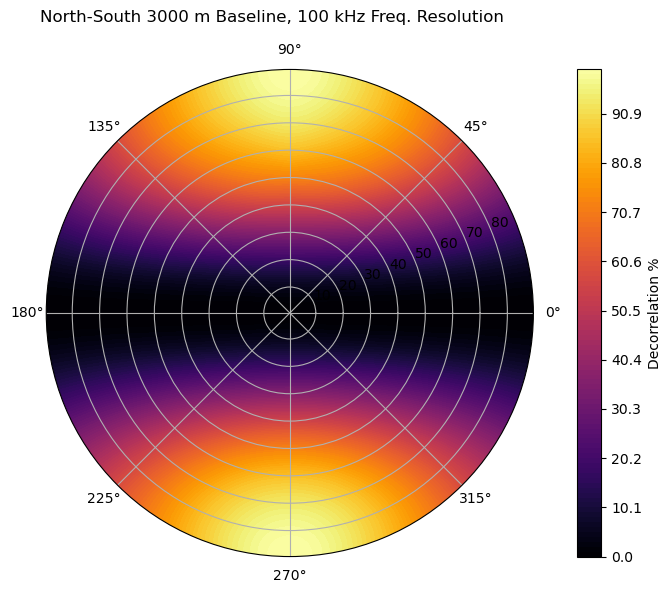

In [23]:
plotting.plot_decorrelation(
    0,
    1,
    300e6,
    100,
    3000,
    0,
    title="East-West 3000 m Baseline, 100 kHz Freq. Resolution",
    show=True,
    phase_center_ra_offset_hr=0,
    phase_center_dec_deg=39.25,
    telescope_lat=39.25,
    mark_north_pole=False,
)
plotting.plot_decorrelation(
    0,
    1,
    300e6,
    100,
    3000,
    45,
    title="3000 m Baseline, 45$^\circ$ North, 100 kHz Freq. Resolution",
    show=True,
    phase_center_ra_offset_hr=0,
    phase_center_dec_deg=39.25,
    telescope_lat=39.25,
    mark_north_pole=False,
)
plotting.plot_decorrelation(
    0,
    1,
    300e6,
    100,
    3000,
    90,
    title="North-South 3000 m Baseline, 100 kHz Freq. Resolution",
    show=True,
    phase_center_ra_offset_hr=0,
    phase_center_dec_deg=39.25,
    telescope_lat=39.25,
    mark_north_pole=False,
)

In [194]:
baseline_length_m = 3000
source_za_deg = 30
freq_hz = 150 * 1e6
step_size_hz = 1e3
c = 3e8
freq_offsets = np.arange(-step_size_hz*200, step_size_hz*200, step_size_hz)

fringe = np.full_like(freq_offsets, np.nan+1j*np.nan, dtype=complex)
for freq_ind, use_offset in enumerate(freq_offsets):
    wl_m = c / (freq_hz + use_offset)
    u = baseline_length_m / wl_m
    u_times_n = u * np.cos(np.deg2rad(source_za_deg))
    fringe[freq_ind] = np.exp(2 * np.pi * 1j * u_times_n)

channel_width = 100 * 1e3
center_freqs = np.arange(np.min(freq_offsets)+ channel_width /2, np.max(freq_offsets), channel_width) + freq_hz
averaged_fringe = np.full_like(center_freqs, np.nan+1j*np.nan, dtype=complex)
for freq_ind, use_freq in enumerate(center_freqs):
    wl_m = c / use_freq
    u = baseline_length_m / wl_m
    u_times_n = u * np.cos(np.deg2rad(source_za_deg))
    averaged_fringe[freq_ind] = np.exp(2 * np.pi * 1j * u_times_n) * np.sinc(channel_width / use_freq * u_times_n)


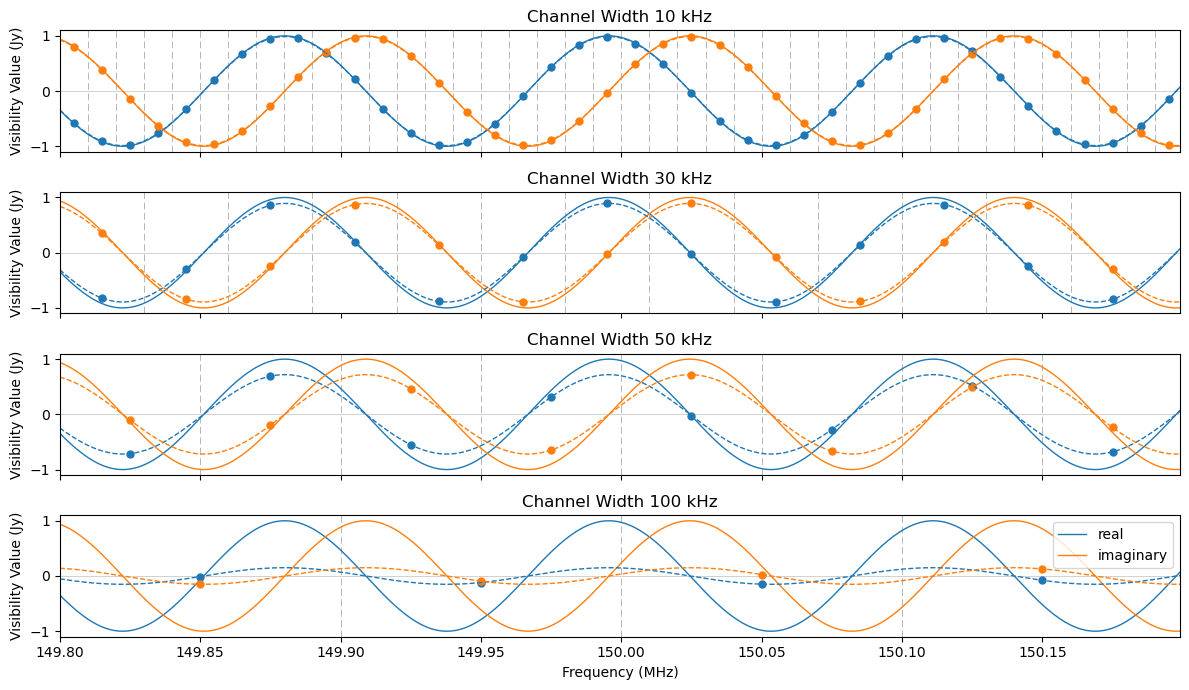

In [227]:
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(12,7), sharex=True)
channel_widths = [10 * 1e3, 30 * 1e3, 50 * 1e3, 100 * 1e3]

baseline_length_m = 3000
source_za_deg = 30
freq_hz = 150 * 1e6
step_size_hz = 1e3
c = 3e8
freq_offsets = np.arange(-step_size_hz*200, step_size_hz*200, step_size_hz)

fringe = np.full_like(freq_offsets, np.nan+1j*np.nan, dtype=complex)
for freq_ind, use_offset in enumerate(freq_offsets):
    wl_m = c / (freq_hz + use_offset)
    u = baseline_length_m / wl_m
    u_times_n = u * np.cos(np.deg2rad(source_za_deg))
    fringe[freq_ind] = np.exp(2 * np.pi * 1j * u_times_n)

for ax_ind, channel_width in enumerate(channel_widths):

    center_freqs = np.arange(np.min(freq_offsets)+ channel_width /2, np.max(freq_offsets), channel_width) + freq_hz
    averaged_fringe = np.full_like(center_freqs, np.nan+1j*np.nan, dtype=complex)
    for freq_ind, use_freq in enumerate(center_freqs):
        wl_m = c / use_freq
        u = baseline_length_m / wl_m
        u_times_n = u * np.cos(np.deg2rad(source_za_deg))
        averaged_fringe[freq_ind] = np.exp(2 * np.pi * 1j * u_times_n) * np.sinc(channel_width / use_freq * u_times_n)


    freq_array = (freq_offsets + freq_hz)/1e6
    ax[ax_ind].plot(freq_array, np.zeros_like(freq_array), "-", linewidth=0.5, color="grey", alpha=0.5)
    ax[ax_ind].plot([(center_freqs - channel_width/2)/1e6, (center_freqs - channel_width/2)/1e6], [-1.1,1.1], "--", color="grey", linewidth=.5, alpha=0.8, dashes=(10, 5))

    ax[ax_ind].plot(freq_array, np.real(fringe), "-", label="real", linewidth=1, color="tab:blue")
    ax[ax_ind].plot(freq_array, np.imag(fringe), "-", label="imaginary", linewidth=1, color="tab:orange")

    ax[ax_ind].plot(center_freqs/1e6, np.real(averaged_fringe), ".", color="tab:blue", markersize=10)
    ax[ax_ind].plot(center_freqs/1e6, np.imag(averaged_fringe), ".", color="tab:orange", markersize=10)
    #ax.plot([(center_freqs - channel_width/2)/1e6, (center_freqs + channel_width/2)/1e6], [np.real(averaged_fringe), np.real(averaged_fringe)], "-", color="tab:blue", alpha=0.5)
    #ax.plot([(center_freqs - channel_width/2)/1e6, (center_freqs + channel_width/2)/1e6], [np.imag(averaged_fringe), np.imag(averaged_fringe)], "-", color="tab:orange", alpha=0.5)
    ax[ax_ind].plot(freq_array, np.real(fringe)*np.sinc(channel_width / use_freq * u_times_n), "--", linewidth=1, color="tab:blue")
    ax[ax_ind].plot(freq_array, np.imag(fringe)*np.sinc(channel_width / use_freq * u_times_n), "--", linewidth=1, color="tab:orange")

    ax[ax_ind].set_ylabel("Visibility Value (Jy)")
    ax[ax_ind].set_xlim([np.min(freq_array), np.max(freq_array)])
    ax[ax_ind].set_ylim([-1.1, 1.1])
    ax[ax_ind].set_title(f"Channel Width {int(channel_width/1e3)} kHz")

ax[-1].legend()
ax[-1].set_xlabel("Frequency (MHz)")
plt.tight_layout()
plt.savefig("/Users/ruby/Downloads/freq_sim.png", dpi=300)


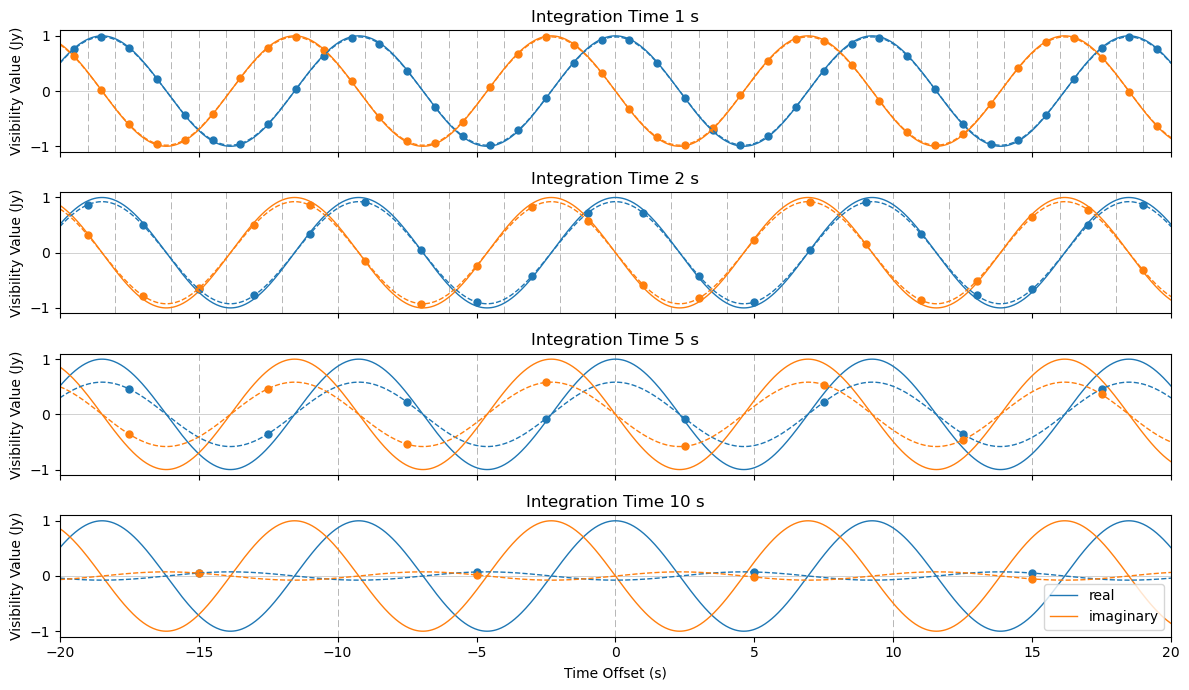

In [226]:
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(12,7), sharex=True)

integration_times = [1, 2, 5, 10]

baseline_length_m = 3000
source_za_deg = 30
freq_hz = 150 * 1e6
c = 3e8

array_lat_deg = 37
source_dec_deg = array_lat_deg-source_za_deg
array_lat_rad = np.deg2rad(array_lat_deg)
source_dec_rad = np.deg2rad(source_dec_deg)
omega = 7.27e-5

wl_m = c / freq_hz
u = baseline_length_m / wl_m

time_array = np.linspace(-20, 20, 1000)
vis_array = np.full_like(time_array, np.nan+1j*np.nan, dtype=complex)
for time_ind, time_offset in enumerate(time_array):
    source_ra_rad = time_offset * omega
    l = -np.cos(source_dec_rad) * np.sin(source_ra_rad)
    #m = np.cos(array_lat_rad) * np.sin(source_lat_rad) - np.sin(array_lat_rad) * np.cos(source_lat_rad) * np.cos(source_ra_rad)
    u_times_n = l*u
    vis_array[time_ind] = np.exp(2*np.pi*1j*u_times_n)

for ax_ind, int_time in enumerate(integration_times):


    center_times = np.arange(np.min(time_array)+ int_time /2, np.max(time_array), int_time)
    averaged_fringe = np.full_like(center_times, np.nan+1j*np.nan, dtype=complex)
    for time_ind, use_time in enumerate(center_times):
        source_ra_rad = use_time * omega
        l = -np.cos(source_dec_rad) * np.sin(source_ra_rad)
        l_dot = omega * np.cos(source_dec_rad) * np.cos(source_ra_rad)
        u_times_n = l * u
        u_times_n_dot = l_dot * u
        averaged_fringe[time_ind] = np.exp(2 * np.pi * 1j * u_times_n) * np.sinc(int_time * u_times_n_dot)
    

    ax[ax_ind].plot(time_array, np.zeros_like(time_array), "-", linewidth=0.5, color="grey", alpha=0.5)
    ax[ax_ind].plot([(center_times - int_time/2), (center_times - int_time/2)], [-1.1,1.1], "--", color="grey", linewidth=.5, alpha=0.8, dashes=(10, 5))

    ax[ax_ind].plot(time_array, np.real(vis_array), "-", label="real", linewidth=1, color="tab:blue")
    ax[ax_ind].plot(time_array, np.imag(vis_array), "-", label="imaginary", linewidth=1, color="tab:orange")

    ax[ax_ind].plot(center_times, np.real(averaged_fringe), ".", color="tab:blue", markersize=10)
    ax[ax_ind].plot(center_times, np.imag(averaged_fringe), ".", color="tab:orange", markersize=10)

    ax[ax_ind].plot(time_array, np.real(vis_array)*np.sinc(int_time * u * omega * np.cos(source_dec_rad)), "--", linewidth=1, color="tab:blue")
    ax[ax_ind].plot(time_array, np.imag(vis_array)*np.sinc(int_time * u * omega * np.cos(source_dec_rad)), "--", linewidth=1, color="tab:orange")

    ax[ax_ind].set_ylabel("Visibility Value (Jy)")
    ax[ax_ind].set_xlim([np.min(time_array), np.max(time_array)])
    ax[ax_ind].set_ylim([-1.1, 1.1])
    ax[ax_ind].set_title(f"Integration Time {int_time} s")

ax[-1].legend()
ax[-1].set_xlabel("Time Offset (s)")
plt.tight_layout()
plt.savefig("/Users/ruby/Downloads/time_sim.png", dpi=300)
